In [4]:
AMOUNT_OF_CARS = 100
t = 0
amount = [AMOUNT_OF_CARS for i in range(4)]
positions = [0 for i in range(4)]
semophor = 0
DIRECTIOBN_CHANGER = 60

while amount != [0, 0, 0, 0] and positions != [0, 0, 0, 0]:

  if t % 7 == 0:
    for i in range(4):
      amount[i] -= 1
      positions[i] += 1
  # if t %

  t += 1

In [5]:
import collections
import random
import math

# --- Константы симуляции ---
DIRECTIONS = ['North', 'South', 'East', 'West']
CARS_PER_DIRECTION = 100
LIGHT_CYCLE_DURATION = 60  # 30 seconds green per direction pair
ARRIVAL_INTERVAL = 10      # New car arrives every 10 seconds per direction
BASE_CROSSING_TIME = 7     # Time for one car to cross the intersection

def simulate_intersection(
    total_cars_per_dir,
    light_green_duration,
    arrival_interval,
    crossing_time_distribution_function,
    delay_side=None,
    delay_amount=0
):
    """
    Основная функция симуляции перекрестка.

    :param total_cars_per_dir: Количество автомобилей с каждой стороны.
    :param light_green_duration: Продолжительность зеленого света (для одной пары направлений).
    :param arrival_interval: Интервал прибытия новых автомобилей.
    :param crossing_time_distribution_function: Функция для расчета времени проезда.
    :param delay_side: Сторона, где водители "зевают" (для усложнения 1).
    :param delay_amount: Величина задержки.
    :return: Словарь со статистикой симуляции.
    """
    # Инициализация очередей (списки для хранения времени прибытия автомобилей)
    queues = {direction: collections.deque() for direction in DIRECTIONS}
    # Статистика: {car_id: waiting_time}
    car_wait_times = {}
    car_total_travel_times = {}

    # Состояние симуляции
    current_time = 0.0
    cars_arrived_count = {direction: 0 for direction in DIRECTIONS}
    cars_processed_count = {direction: 0 for direction in DIRECTIONS}

    # Светофор: 0-30s North-South green, 30-60s East-West green
    light_state = 'North-South'

    # Переменные для отслеживания событий
    next_arrival_time = {direction: 0 for direction in DIRECTIONS}
    intersection_available_time = 0.0 # Время, когда перекресток будет свободен для следующего автомобиля

    simulation_active = True
    while simulation_active:
        current_time += 1.0

        # --- 1. Прибытие автомобилей ---
        for direction in DIRECTIONS:
            if current_time >= next_arrival_time[direction] and cars_arrived_count[direction] < total_cars_per_dir:
                queues[direction].append(current_time)
                cars_arrived_count[direction] += 1
                next_arrival_time[direction] += arrival_interval

        # --- 2. Логика светофора ---
        if current_time % LIGHT_CYCLE_DURATION == 0:
            if light_state == 'North-South':
                light_state = 'East-West'
            else:
                light_state = 'North-South'

        # --- 3. Обработка автомобилей на перекрестке ---
        # Определяем, какие направления сейчас имеют зеленый свет
        green_directions = ['North', 'South'] if light_state == 'North-South' else ['East', 'West']

        # Проверяем, может ли автомобиль проехать
        for direction in green_directions:
            if queues[direction] and intersection_available_time <= current_time:
                # Берем первый автомобиль из очереди
                arrival_time = queues[direction].popleft()

                # Рассчитываем время проезда, используя функцию распределения
                crossing_duration = crossing_time_distribution_function()

                # Усложнение 1: Задержка "зевающего" водителя
                car_start_time = current_time
                if delay_side == direction:
                    car_start_time += delay_amount

                # Обновляем время, когда перекресток будет свободен для следующего автомобиля
                intersection_available_time = car_start_time + crossing_duration

                # Статистика
                wait_time = car_start_time - arrival_time
                car_id = f"{direction}-{cars_processed_count[direction]}"
                car_wait_times[car_id] = wait_time
                cars_processed_count[direction] += 1

        # --- 4. Условие завершения симуляции ---
        if sum(cars_processed_count.values()) == sum(cars_arrived_count.values()) and simulation_active:
            simulation_active = False

    # --- Сбор статистики ---
    total_wait_time = sum(car_wait_times.values())
    total_cars_processed = len(car_wait_times)
    avg_wait_time = total_wait_time / total_cars_processed if total_cars_processed > 0 else 0

    # Расчет "вероятности отказа" (P(wait time > threshold))
    failure_threshold = 60 # 60 секунд = 1 полный цикл светофора
    failures = sum(1 for wait_time in car_wait_times.values() if wait_time > failure_threshold)
    probability_of_failure = failures / total_cars_processed if total_cars_processed > 0 else 0

    return {
        "avg_wait_time": avg_wait_time,
        "max_queue_length": max(len(queue) for queue in queues.values()),
        "probability_of_failure": probability_of_failure,
        "total_time": current_time,
        "total_processed": total_cars_processed
    }

# --- Распределения для усложнения 2 ---

def fixed_crossing_time():
    """Базовое фиксированное время проезда (7 секунд)."""
    return BASE_CROSSING_TIME

def normal_crossing_time():
    """Нормальное распределение (среднее 7, стандартное отклонение 1)."""
    # Гауссово распределение, обрезаем, чтобы не было отрицательных значений.
    return max(3, random.gauss(BASE_CROSSING_TIME, 1))

def exponential_crossing_time():
    """Экспоненциальное распределение (среднее 7)."""
    # Параметр лямбда = 1/mu (среднее).
    return max(0.5, random.expovariate(1.0 / BASE_CROSSING_TIME))

# --- Запуск симуляций ---

# Модель 1: Базовая симуляция
results_baseline = simulate_intersection(
    total_cars_per_dir=CARS_PER_DIRECTION,
    light_green_duration=LIGHT_CYCLE_DURATION / 2,
    arrival_interval=ARRIVAL_INTERVAL,
    crossing_time_distribution_function=fixed_crossing_time
)

# Модель 2: С усложнением 1 (задержка водителей)
results_with_delay = simulate_intersection(
    total_cars_per_dir=CARS_PER_DIRECTION,
    light_green_duration=LIGHT_CYCLE_DURATION / 2,
    arrival_interval=ARRIVAL_INTERVAL,
    crossing_time_distribution_function=fixed_crossing_time,
    delay_side='North',
    delay_amount=2
)

# Модель 3: С усложнением 2 (нормальное распределение)
results_normal_dist = simulate_intersection(
    total_cars_per_dir=CARS_PER_DIRECTION,
    light_green_duration=LIGHT_CYCLE_DURATION / 2,
    arrival_interval=ARRIVAL_INTERVAL,
    crossing_time_distribution_function=normal_crossing_time
)

# Модель 3: С усложнением 2 (экспоненциальное распределение)
results_exponential_dist = simulate_intersection(
    total_cars_per_dir=CARS_PER_DIRECTION,
    light_green_duration=LIGHT_CYCLE_DURATION / 2,
    arrival_interval=ARRIVAL_INTERVAL,
    crossing_time_distribution_function=exponential_crossing_time
)

# --- Вывод результатов ---
print("--- Результаты симуляции перекрестка ---")

def print_results(title, results):
    print(f"\n{title}:")
    print(f"  Общее время симуляции: {math.ceil(results['total_time'])} секунд")
    print(f"  Среднее время ожидания автомобиля: {results['avg_wait_time']:.2f} секунд")
    print(f"  Максимальная длина очереди: {results['max_queue_length']} автомобилей")
    print(f"  Вероятность отказа (Wait > 60s): {results['probability_of_failure']:.2f}")

print_results("1. Базовая модель (фиксированное время проезда)", results_baseline)
print_results("2. Усложнение 1 (Задержка водителей на стороне North)", results_with_delay)
print_results("3. Усложнение 2 (Нормальное распределение времени проезда)", results_normal_dist)
print_results("3. Усложнение 2 (Экспоненциальное распределение времени проезда)", results_exponential_dist)

--- Результаты симуляции перекрестка ---

1. Базовая модель (фиксированное время проезда):
  Общее время симуляции: 2834 секунд
  Среднее время ожидания автомобиля: 902.79 секунд
  Максимальная длина очереди: 0 автомобилей
  Вероятность отказа (Wait > 60s): 0.94

2. Усложнение 1 (Задержка водителей на стороне North):
  Общее время симуляции: 3127 секунд
  Среднее время ожидания автомобиля: 1051.42 секунд
  Максимальная длина очереди: 0 автомобилей
  Вероятность отказа (Wait > 60s): 0.96

3. Усложнение 2 (Нормальное распределение времени проезда):
  Общее время симуляции: 3067 секунд
  Среднее время ожидания автомобиля: 1009.83 секунд
  Максимальная длина очереди: 0 автомобилей
  Вероятность отказа (Wait > 60s): 0.94

3. Усложнение 2 (Экспоненциальное распределение времени проезда):
  Общее время симуляции: 3243 секунд
  Среднее время ожидания автомобиля: 1068.95 секунд
  Максимальная длина очереди: 0 автомобилей
  Вероятность отказа (Wait > 60s): 0.94


/tmp/ipython-input-315171922.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='Total Time (s)', data=df, ax=axes[0], palette='viridis')
/tmp/ipython-input-315171922.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='Avg Wait Time (s)', data=df, ax=axes[1], palette='plasma')
/tmp/ipython-input-315171922.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='Prob of Failure (>60s)', data=df, ax=axes[2], palette='magma')


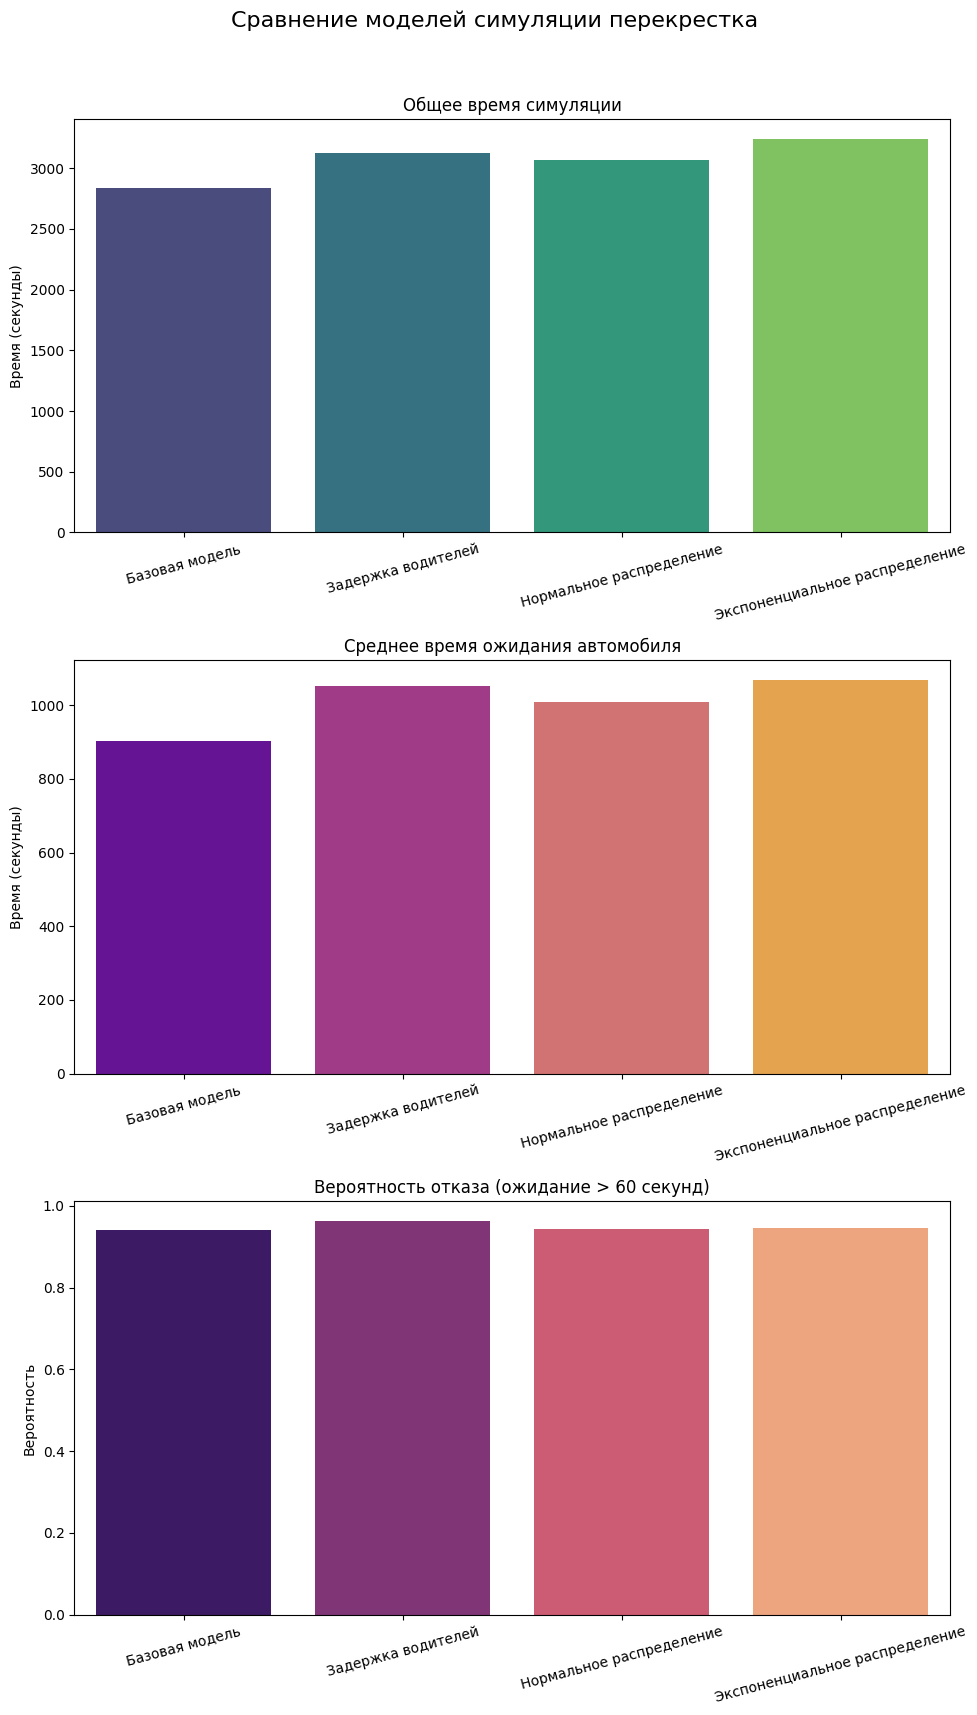

In [9]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Prepare data for plotting
data = {
    'Model': ['Базовая модель', 'Задержка водителей', 'Нормальное распределение', 'Экспоненциальное распределение'],
    'Total Time (s)': [results_baseline['total_time'], results_with_delay['total_time'], results_normal_dist['total_time'], results_exponential_dist['total_time']],
    'Avg Wait Time (s)': [results_baseline['avg_wait_time'], results_with_delay['avg_wait_time'], results_normal_dist['avg_wait_time'], results_exponential_dist['avg_wait_time']],
    'Prob of Failure (>60s)': [results_baseline['probability_of_failure'], results_with_delay['probability_of_failure'], results_normal_dist['probability_of_failure'], results_exponential_dist['probability_of_failure']]
}
df = pd.DataFrame(data)

# Create subplots for each metric
fig, axes = plt.subplots(3, 1, figsize=(10, 18))
fig.suptitle('Сравнение моделей симуляции перекрестка', fontsize=16)

# Plot Total Time
sns.barplot(x='Model', y='Total Time (s)', data=df, ax=axes[0], palette='viridis')
axes[0].set_title('Общее время симуляции')
axes[0].set_ylabel('Время (секунды)')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=15)

# Plot Average Wait Time
sns.barplot(x='Model', y='Avg Wait Time (s)', data=df, ax=axes[1], palette='plasma')
axes[1].set_title('Среднее время ожидания автомобиля')
axes[1].set_ylabel('Время (секунды)')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=15)

# Plot Probability of Failure
sns.barplot(x='Model', y='Prob of Failure (>60s)', data=df, ax=axes[2], palette='magma')
axes[2].set_title('Вероятность отказа (ожидание > 60 секунд)')
axes[2].set_ylabel('Вероятность')
axes[2].set_xlabel('')
axes[2].tick_params(axis='x', rotation=15)

plt.tight_layout(rect=[0, 0.03, 1, 0.96])
plt.show()